In [1]:
import os, json, contextlib
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm
import pandas as pd
from scipy.ndimage import affine_transform
from scipy.ndimage import label as cc_label
from scipy.stats import spearmanr
from medpy.metric.binary import hd95 as medpy_hd95
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

SPLITS_DIR = Path(r"D:\master_experiments\data\splits\BraTS2020_Splits")
META_PATH  = SPLITS_DIR / "splits_metadata.json"

UNET2D_BASE = Path(r"D:\master_experiments\models_configs\UNet2D_BraTS2020")
UNET2D_CKPT = UNET2D_BASE / "checkpoints"
UNET2D_PRED = UNET2D_BASE / "predictions_test"
UNET2D_LOGS = UNET2D_BASE / "logs"
UNET2D_DATA = UNET2D_BASE / "slice_dataset"

for p in [UNET2D_BASE, UNET2D_CKPT, UNET2D_PRED, UNET2D_LOGS,
          UNET2D_DATA / "images" / "train", UNET2D_DATA / "images" / "val",
          UNET2D_DATA / "labels" / "train", UNET2D_DATA / "labels" / "val"]:
    p.mkdir(parents=True, exist_ok=True)


MODS      = ["flair", "t1", "t1ce", "t2"]
N_CLASSES = 4
PATCH_2D  = 192
NUM_ITERS_PER_EPOCH = 250

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
NW      = 0 if os.name == "nt" else 4

print("Device:", DEVICE)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory/1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER | VRAM: 12.9 GB


In [2]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

train_ids = meta["ids"]["train"]
val_ids = meta["ids"]["val"]
test_ids = meta["ids"]["test"]

train_set, val_set, test_set = set(train_ids), set(val_ids), set(test_ids)

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

print("Counts:", len(train_ids), len(val_ids), len(test_ids))
print("OK: sem repetição entre splits")

Counts: 245 52 53
OK: sem repetição entre splits


In [3]:
# Funções auxiliares

def case_dir(split_name: str, case_id: str) -> Path:
    return SPLITS_DIR / split_name / case_id

def find_file(folder: Path, key: str) -> Path:
    for cand in [folder / f"{key}.nii.gz", folder / f"{key}.nii"]:
        if cand.exists():
            return cand
    cands = sorted(list(folder.glob(f"*{key}*.nii*")))
    if key == "t1":
        cands = [c for c in cands if "t1ce" not in c.name.lower()]
    if not cands:
        raise FileNotFoundError(f"{key} not found in {folder}")
    return cands[0]

def load_arr(p) -> np.ndarray:
    return np.squeeze(np.asanyarray(nib.load(str(p)).dataobj))

def norm_zscore_fg(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mask = x > 0
    if mask.sum() == 0:
        return np.zeros_like(x)
    mean = float(x[mask].mean())
    std  = float(x[mask].std()) + 1e-8
    out  = (x - mean) / std
    out[~mask] = 0.0
    return out

def norm01(x, p1=1, p99=99) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p1, p99])
    if hi <= lo:
        return np.zeros_like(x)
    return np.clip((x - lo) / (hi - lo), 0, 1)

def load_brats_seg(path) -> np.ndarray:
    data = load_arr(path).astype(np.int16)
    data[data == 4] = 3
    return data

def dice_score(a, b) -> float:
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def pick_best_slice(seg, axis=2) -> int:
    counts = np.sum(seg > 0, axis=tuple(i for i in range(3) if i != axis))
    return int(np.argmax(counts))

for cid in train_ids[:3]:
    d = case_dir("train", cid)
    assert d.exists()
    _ = [find_file(d, m) for m in MODS]
    _ = find_file(d, "seg")
print("Helpers OK")

Helpers OK


In [4]:
# Pre-extracao de slices 2D para .npy (disco) - acelera o treino evitando
# carregar volumes 3D inteiros a cada __getitem__.
#
#  Cada slice axial com lesao vira uma amostra. Background-only slices sao
#  amostradas em 33% para fornecer exemplos negativos sem inflar o dataset.
#  Salva apenas se nao existir ainda (idempotente).

NEG_RATE = 0.33

def export_case_to_slices(cid: str, src_split: str, dst_split: str, rng: np.random.Generator):
    d = case_dir(src_split, cid)
    seg_3d = load_brats_seg(find_file(d, "seg"))
    chans_3d = [norm_zscore_fg(load_arr(find_file(d, m))) for m in MODS]
    H, W, D = seg_3d.shape
    n_saved = 0
    for z in range(D):
        seg2d = seg_3d[:, :, z]
        has_lesion = (seg2d > 0).any()
        if not has_lesion and rng.random() > NEG_RATE:
            continue
        img_path = UNET2D_DATA / "images" / dst_split / f"{cid}_z{z:03d}.npy"
        lbl_path = UNET2D_DATA / "labels" / dst_split / f"{cid}_z{z:03d}.npy"
        if img_path.exists() and lbl_path.exists():
            n_saved += 1
            continue
        img2d = np.stack([c[:, :, z] for c in chans_3d], axis=0).astype(np.float32)
        np.save(img_path, img2d)
        np.save(lbl_path, seg2d.astype(np.int16))
        n_saved += 1
    return n_saved

rng = np.random.default_rng(42)

tot_tr = 0
for cid in tqdm(train_ids, desc="Export train -> slices"):
    tot_tr += export_case_to_slices(cid, "train", "train", rng)

tot_va = 0
for cid in tqdm(val_ids, desc="Export val -> slices"):
    tot_va += export_case_to_slices(cid, "val", "val", rng)

print(f"Slices train: {tot_tr} | val: {tot_va}")

Export val -> slices: 100%|██████████| 52/52 [01:01<00:00,  1.19s/it]

Slices train: 23308 | val: 5053


In [5]:
class BraTSSliceDataset(Dataset):

    def __init__(self, ids_list, split_name, patch=PATCH_2D,
                 augment=True, num_iterations=None):
        self.ids            = ids_list
        self.split          = split_name
        self.patch          = patch
        self.aug            = augment
        self.num_iterations = num_iterations
        # Lista os .npy do split que pertencem aos ids fornecidos
        ids_set = set(ids_list)
        img_dir = UNET2D_DATA / "images" / split_name
        self.slice_files = sorted([
            p for p in img_dir.glob("*.npy")
            if p.stem.rsplit("_z", 1)[0] in ids_set
        ])

    def __len__(self):
        return self.num_iterations if self.num_iterations is not None else len(self.slice_files)

    def _crop_2d(self, arrays, patch):
        seg  = arrays[-1]
        H, W = seg.shape
        half = patch // 2
        if np.random.rand() < 0.33 or not (seg > 0).any():
            cy = np.random.randint(half, max(H - half, half + 1))
            cx = np.random.randint(half, max(W - half, half + 1))
        else:
            coords = np.argwhere(seg > 0)
            cy, cx = coords[np.random.randint(len(coords))]
        cy = int(np.clip(cy, half, H - half))
        cx = int(np.clip(cx, half, W - half))
        return [a[cy-half:cy+half, cx-half:cx+half] for a in arrays]

    def _augment(self, imgs, seg):
        if np.random.rand() < 0.2:
            angle  = np.random.uniform(-30, 30) * np.pi / 180.0
            scale  = np.random.uniform(0.85, 1.25)
            cos_a  = np.cos(angle) / scale
            sin_a  = np.sin(angle) / scale
            matrix = np.array([[ cos_a, sin_a],
                               [-sin_a, cos_a]], dtype=np.float64)
            shape  = np.array(imgs[0].shape)
            center = (shape - 1) / 2.0
            offset = center - matrix @ center
            imgs = [affine_transform(im, matrix, offset=offset, order=1,
                                     mode='constant', cval=0).astype(np.float32)
                    for im in imgs]
            seg  = affine_transform(seg.astype(np.int16), matrix, offset=offset,
                                    order=0, mode='constant', cval=0).astype(np.int16)
        for ax in range(2):
            if np.random.rand() > 0.5:
                imgs = [np.flip(im, axis=ax).copy() for im in imgs]
                seg  = np.flip(seg,  axis=ax).copy()
        bright = np.random.uniform(0.85, 1.15) if np.random.rand() > 0.5 else 1.0
        aug_imgs = []
        for im in imgs:
            im = im * bright
            if np.random.rand() > 0.5:
                im = im + np.random.normal(0, 0.05, im.shape).astype(np.float32)
            aug_imgs.append(im.astype(np.float32))
        return aug_imgs, seg

    def __getitem__(self, idx):
        if self.num_iterations is not None:
            f_img = self.slice_files[np.random.randint(len(self.slice_files))]
        else:
            f_img = self.slice_files[idx]
        f_lbl = UNET2D_DATA / "labels" / self.split / f_img.name
        img = np.load(f_img)        # [4, H, W] float32 (z-score ja aplicado no export)
        seg = np.load(f_lbl)        # [H, W] int16
        imgs = [img[c] for c in range(img.shape[0])]
        cropped     = self._crop_2d(imgs + [seg], self.patch)
        imgs, seg   = cropped[:-1], cropped[-1]
        if self.aug:
            imgs, seg = self._augment(imgs, seg)
        vol_t = torch.from_numpy(np.stack(imgs, axis=0).astype(np.float32))
        seg_t = torch.from_numpy(seg.astype(np.int64))
        return vol_t, seg_t

In [6]:
# ═══════════════════════════════════════════════════════════
#  Instanciação da U-Net 2D clássica para segmentação fatia-a-fatia
# ═══════════════════════════════════════════════════════════
#
#  base          = 32  → canais base; encoder = [32, 64, 128, 256, 512]
#  niveis        = 4   → 4 downsamplings (max-pool 2x2) + 4 upsamplings
#  blocos        = DoubleConv (Conv-IN-LeakyReLU x2)
#  upsample      = ConvTranspose2d 2x2 + skip connection (concat)
#
#  num_input_channels = 4  → FLAIR, T1, T1ce, T2
#  num_classes        = 4  → {0: bg, 1: necrose/non-enh, 2: edema, 3: ET}
# ═══════════════════════════════════════════════════════════

class _DoubleConv2D(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
            nn.InstanceNorm2d(c_out, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False),
            nn.InstanceNorm2d(c_out, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet2D(nn.Module):
    def __init__(self, in_channels=4, n_classes=4, base=32):
        super().__init__()
        c = [base, base*2, base*4, base*8, base*16]
        self.enc1 = _DoubleConv2D(in_channels, c[0])
        self.enc2 = _DoubleConv2D(c[0], c[1])
        self.enc3 = _DoubleConv2D(c[1], c[2])
        self.enc4 = _DoubleConv2D(c[2], c[3])
        self.bott = _DoubleConv2D(c[3], c[4])
        self.up4  = nn.ConvTranspose2d(c[4], c[3], 2, stride=2)
        self.dec4 = _DoubleConv2D(c[4], c[3])
        self.up3  = nn.ConvTranspose2d(c[3], c[2], 2, stride=2)
        self.dec3 = _DoubleConv2D(c[3], c[2])
        self.up2  = nn.ConvTranspose2d(c[2], c[1], 2, stride=2)
        self.dec2 = _DoubleConv2D(c[2], c[1])
        self.up1  = nn.ConvTranspose2d(c[1], c[0], 2, stride=2)
        self.dec1 = _DoubleConv2D(c[1], c[0])
        self.out  = nn.Conv2d(c[0], n_classes, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        e1 = self.enc1(x);            p1 = self.pool(e1)
        e2 = self.enc2(p1);           p2 = self.pool(e2)
        e3 = self.enc3(p2);           p3 = self.pool(e3)
        e4 = self.enc4(p3);           p4 = self.pool(e4)
        b  = self.bott(p4)
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


UNET2D_BASE_CH = 32

model = UNet2D(in_channels=4, n_classes=N_CLASSES, base=UNET2D_BASE_CH).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

print("=" * 55)
print(f"  U-Net 2D (base={UNET2D_BASE_CH})  —  Configuração do modelo")
print("=" * 55)
print(f"  Canais de entrada (in_channels) : {4}")
print(f"  Canais de saída  (n_classes)    : {N_CLASSES}")
print(f"  Slice 2D                        : {PATCH_2D}x{PATCH_2D}")
print(f"  Device                          : {DEVICE}")
print(f"  Parâmetros treináveis           : {n_params:.2f} M")
print("=" * 55)

  U-Net 2D (base=32)  —  Configuração do modelo
  Canais de entrada (in_channels) : 4
  Canais de saída  (n_classes)    : 4
  Slice 2D                        : 192x192
  Device                          : cuda
  Parâmetros treináveis           : 7.76 M


In [7]:
class DiceCELoss(nn.Module):

    def __init__(self):
        super().__init__()

    def _soft_dice(self, pred_soft, target_oh):
        smooth = 1e-5
        dims   = (0, 2, 3)
        p = pred_soft[:, 1:]
        t = target_oh[:, 1:]
        inter = (p * t).sum(dims)
        denom = p.sum(dims) + t.sum(dims)
        return 1.0 - ((2.0 * inter + smooth) / (denom + smooth)).mean()

    def forward(self, logits, target):
        n_cls = logits.shape[1]
        oh    = F.one_hot(target, n_cls).permute(0, 3, 1, 2).float()
        soft  = torch.softmax(logits, dim=1)
        return self._soft_dice(soft, oh) + F.cross_entropy(logits, target)

In [8]:
TRAIN_EPOCHS = 100
BATCH_SIZE   = 16
ACCUM_STEPS  = 1
LR           = 1e-3
GRAD_CLIP    = 1.0


def train_unet2d(model, train_ids, val_ids,
                 epochs=TRAIN_EPOCHS, save_dir=UNET2D_CKPT):

    crit   = DiceCELoss()
    scaler = GradScaler("cuda") if USE_AMP else None

    ds_tr = BraTSSliceDataset(train_ids, "train", augment=True,
                              num_iterations=NUM_ITERS_PER_EPOCH * BATCH_SIZE)
    ds_va = BraTSSliceDataset(val_ids,   "val",   augment=False,
                              num_iterations=len(val_ids) * 8)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=NW, pin_memory=USE_AMP)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NW, pin_memory=USE_AMP)

    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)

    tr_losses, va_losses = [], []
    best_val = float("inf")

    for epoch in range(epochs):
        model.train()
        running = 0.0
        opt.zero_grad()

        for step, (vol, seg) in enumerate(
                tqdm(dl_tr, desc=f"Ep {epoch+1:3d}/{epochs} train", leave=False)):
            vol = vol.to(DEVICE)
            seg = seg.to(DEVICE)

            with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                out  = model(vol)
                loss = crit(out, seg) / ACCUM_STEPS

            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            if (step + 1) % ACCUM_STEPS == 0:
                if scaler:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    scaler.step(opt); scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    opt.step()
                opt.zero_grad()

            running += loss.item() * ACCUM_STEPS

        avg_tr = running / max(len(dl_tr), 1)
        tr_losses.append(avg_tr)
        sched.step()

        model.eval()
        running_v = 0.0
        with torch.no_grad():
            for vol, seg in dl_va:
                vol = vol.to(DEVICE); seg = seg.to(DEVICE)
                with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                    running_v += crit(model(vol), seg).item()

        avg_va = running_v / max(len(dl_va), 1)
        va_losses.append(avg_va)
        print(f"  Ep {epoch+1:3d} | tr={avg_tr:.4f} | va={avg_va:.4f}")

        if avg_va < best_val:
            best_val = avg_va
            torch.save(model.state_dict(), save_dir / "unet2d_best.pth")
            print(f"    ✓ Melhor checkpoint salvo (val={best_val:.4f})")

    history = {"train": tr_losses, "val": va_losses}
    with open(UNET2D_LOGS / "train_history.json", "w") as f:
        json.dump(history, f, indent=2)
    print("\nTreino concluído.")
    return history


train_history = train_unet2d(model, train_ids, val_ids)

  Ep   1 | tr=0.9881 | va=0.4754
    ✓ Melhor checkpoint salvo (val=0.4754)


  Ep   2 | tr=0.4140 | va=0.3739
    ✓ Melhor checkpoint salvo (val=0.3739)


  Ep   3 | tr=0.3556 | va=0.3705
    ✓ Melhor checkpoint salvo (val=0.3705)


  Ep   4 | tr=0.3293 | va=0.3198
    ✓ Melhor checkpoint salvo (val=0.3198)


  Ep   5 | tr=0.3181 | va=0.3433


...

  Ep  96 | tr=0.1646 | va=0.2694


  Ep  97 | tr=0.1627 | va=0.2484


  Ep  98 | tr=0.1675 | va=0.2540


  Ep  99 | tr=0.1582 | va=0.2734


  Ep 100 | tr=0.1610 | va=0.3045

Treino concluído.


In [9]:
def slicewise_inference(model, vol_4ch: np.ndarray, n_classes: int) -> np.ndarray:
    # vol_4ch: [4, H, W, D] - itera ao longo de D (eixo axial), prediz cada fatia 2D e remonta o volume 3D
    model.eval()
    _, H, W, D = vol_4ch.shape

    # Pad H/W para multiplos de 16 (4 downsamplings da U-Net 2D = stride 16)
    pad_h = (16 - H % 16) % 16
    pad_w = (16 - W % 16) % 16

    pred_3d = np.zeros((H, W, D), dtype=np.int16)

    with torch.no_grad():
        for z in range(D):
            sl = vol_4ch[:, :, :, z]  # [4, H, W]
            if pad_h or pad_w:
                sl = np.pad(sl, ((0, 0), (0, pad_h), (0, pad_w)), mode="constant")
            t = torch.from_numpy(sl[None]).to(DEVICE)  # [1, 4, H', W']
            with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                out = model(t)
                prob = torch.softmax(out, dim=1)[0].cpu().float().numpy()
            pred_2d = prob.argmax(axis=0).astype(np.int16)
            pred_3d[:, :, z] = pred_2d[:H, :W]

    return pred_3d


print("slicewise_inference OK")

slicewise_inference OK


In [10]:
# Carrega melhor checkpoint e gera predições no conjunto de teste
model.load_state_dict(
    torch.load(UNET2D_CKPT / "unet2d_best.pth", map_location=DEVICE,
               weights_only=True))
print("Melhor modelo U-Net 2D carregado.")

model.eval()
print(f"\nGerando predições → {UNET2D_PRED}")

for cid in tqdm(test_ids, desc="Predição test"):
    out_path = UNET2D_PRED / f"{cid}.nii.gz"
    d   = case_dir("test", cid)
    ref = nib.load(str(find_file(d, "flair")))
    imgs = [norm_zscore_fg(load_arr(find_file(d, m))) for m in MODS]
    vol  = np.stack(imgs, axis=0).astype(np.float32)  # [4, H, W, D]

    pred = slicewise_inference(model, vol, n_classes=N_CLASSES)  # [H, W, D]
    nib.save(nib.Nifti1Image(pred, ref.affine, ref.header), str(out_path))

print("Predições concluídas.")

Melhor modelo U-Net 2D carregado.

Gerando predições → D:\master_experiments\models_configs\UNet2D_BraTS2020\predictions_test


Predição test: 100%|██████████| 53/53 [01:33<00:00,  1.77s/it]

Predições concluídas.


In [11]:
# Dice global por caso

def get_pred_path(cid: str) -> Path:
    for ext in [".nii.gz", ".nii"]:
        p = UNET2D_PRED / f"{cid}{ext}"
        if p.exists():
            return p
    raise FileNotFoundError(f"Pred não encontrada para {cid}")

def dice(a, b) -> float:
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

rows = []
for cid in tqdm(test_ids, desc="Dice por caso"):
    gt = load_brats_seg(find_file(case_dir("test", cid), "seg"))
    pr = load_arr(get_pred_path(cid)).astype(np.int16)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt==1)|(gt==3)),         ((pr==1)|(pr==3)))

    rows.append({"id": cid,
                 "dice_c1": d1, "dice_c2": d2, "dice_ET": d3,
                 "dice_WT": wt, "dice_TC": tc})

df = pd.DataFrame(rows)
df.to_csv(UNET2D_LOGS / "dice_test.csv", index=False)
df.describe()

Dice por caso: 100%|██████████| 53/53 [00:06<00:00,  7.88it/s]


,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,0.666552,0.794091,0.808865,0.885745,0.848192
std,0.288118,0.131566,0.184837,0.098807,0.175237
min,0.014567,0.493022,0.070400,0.521639,0.104089
25%,0.552761,0.694203,0.750776,0.862853,0.832477
50%,0.770361,0.836013,0.896682,0.919226,0.917813
75%,0.892804,0.896823,0.911070,0.944656,0.951648
max,0.983012,0.952847,0.961175,0.968033,0.974801


In [12]:
# HD95 (Hausdorff Distance 95th percentile) por caso — mesmo padrão do Dice global, por regiões

def hd95_score(gt_mask, pr_mask, voxelspacing=None):
    gt_b = gt_mask.astype(bool)
    pr_b = pr_mask.astype(bool)
    if not gt_b.any() and not pr_b.any():
        return 0.0
    if not gt_b.any() or not pr_b.any():
        return np.nan
    return float(medpy_hd95(pr_b, gt_b, voxelspacing=voxelspacing))


hd95_rows = []
for cid in tqdm(test_ids, desc="HD95 por caso"):
    gt_path = find_file(case_dir("test", cid), "seg")
    pr_path = get_pred_path(cid)

    gt = load_brats_seg(gt_path)
    pr = load_arr(pr_path).astype(np.int16)

    spacing = nib.load(str(gt_path)).header.get_zooms()[:3]

    h1  = hd95_score(gt == 1, pr == 1, voxelspacing=spacing)
    h2  = hd95_score(gt == 2, pr == 2, voxelspacing=spacing)
    h3  = hd95_score(gt == 3, pr == 3, voxelspacing=spacing)
    hwt = hd95_score(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)), voxelspacing=spacing)
    htc = hd95_score(((gt == 1) | (gt == 3)),   ((pr == 1) | (pr == 3)),   voxelspacing=spacing)

    hd95_rows.append({
        "id":       cid,
        "hd95_c1":  h1,
        "hd95_c2":  h2,
        "hd95_ET":  h3,
        "hd95_WT":  hwt,
        "hd95_TC":  htc,
    })

df_hd95 = pd.DataFrame(hd95_rows)
df_hd95.to_csv(UNET2D_LOGS / "hd95_test.csv", index=False)
df_hd95.describe()

HD95 por caso: 100%|██████████| 53/53 [04:42<00:00,  5.33s/it]


,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,8.987342,8.060451,5.605754,10.273058,7.408033
std,15.751590,9.887143,15.070983,18.389774,15.857407
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.828427,2.236068,1.000000,2.236068,1.414214
50%,5.099020,4.242641,1.414214,3.162278,2.449490
75%,9.055385,8.062258,3.000000,7.348469,5.830952
max,105.142283,46.272019,105.739538,100.723632,106.075445


In [13]:
# Análise condicional 1/3: frequência de presença de cada classe no GT

presence_rows = []
for cid in tqdm(test_ids, desc="Presença GT"):
    gt = load_brats_seg(find_file(case_dir("test", cid), "seg"))
    presence_rows.append({
        "id":     cid,
        "has_c1": bool((gt == 1).any()),
        "has_c2": bool((gt == 2).any()),
        "has_ET": bool((gt == 3).any()),
        "has_WT": bool(((gt==1)|(gt==2)|(gt==3)).any()),
        "has_TC": bool(((gt==1)|(gt==3)).any()),
    })
pres_df = pd.DataFrame(presence_rows)
df_full = df.merge(pres_df, on="id")

df_presence = pd.DataFrame([
    {"classe":     col,
     "n_presente": int(df_full[col].sum()),
     "n_total":    len(df_full),
     "pct":        100.0 * df_full[col].sum() / len(df_full)}
    for col in ["has_c1", "has_c2", "has_ET", "has_WT", "has_TC"]
])
df_presence.round(2)

Presença GT: 100%|██████████| 53/53 [00:02<00:00, 24.84it/s]


,classe,n_presente,n_total,pct
0,has_c1,53,53,100.0
1,has_c2,53,53,100.0
2,has_ET,53,53,100.0
3,has_WT,53,53,100.0
4,has_TC,53,53,100.0


In [14]:
# Análise condicional 2/3: Dice somente nos casos em que a classe está presente no GT
pairs = [("dice_c1","has_c1"), ("dice_c2","has_c2"), ("dice_ET","has_ET"),
         ("dice_WT","has_WT"), ("dice_TC","has_TC")]
df_conditional = pd.DataFrame({
    col: df_full.loc[df_full[has], col].reset_index(drop=True)
    for col, has in pairs
})
df_conditional.to_csv(UNET2D_LOGS / "dice_conditional.csv", index=False)
print("\nDice condicional:")
df_conditional.describe().round(4)


Dice condicional:


,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,53.0000,53.0000,53.0000,53.0000,53.0000
mean,0.6666,0.7941,0.8089,0.8857,0.8482
std,0.2881,0.1316,0.1848,0.0988,0.1752
min,0.0146,0.4930,0.0704,0.5216,0.1041
25%,0.5528,0.6942,0.7508,0.8629,0.8325
50%,0.7704,0.8360,0.8967,0.9192,0.9178
75%,0.8928,0.8968,0.9111,0.9447,0.9516
max,0.9830,0.9528,0.9612,0.9680,0.9748


In [15]:
# Análise condicional 3/3: bimodalidade — % de Dice=0 e % de Dice≈1

df_bimodality = pd.DataFrame([
    {"metric":         col,
     "pct_dice_zero": float((df_full[col] == 0.0).mean()) * 100,
     "pct_dice_one":  float((df_full[col] >= 0.999).mean()) * 100}
    for col, _ in pairs
])
df_bimodality.to_csv(UNET2D_LOGS / "dice_bimodality.csv", index=False)
df_bimodality.round(2)

,metric,pct_dice_zero,pct_dice_one
0,dice_c1,0.0,0.0
1,dice_c2,0.0,0.0
2,dice_ET,0.0,0.0
3,dice_WT,0.0,0.0
4,dice_TC,0.0,0.0


In [16]:
# Lesion-wise Dice (LWD) — métrica primária do BraTS 2023+

LW_MIN_SIZE = 50

def lesion_wise_dice(gt_mask: np.ndarray, pr_mask: np.ndarray,
                     min_size: int = LW_MIN_SIZE) -> float:
    structure = np.ones((3, 3, 3), dtype=int)
    if not gt_mask.any() and not pr_mask.any():
        return 1.0
    gt_lab, n_gt = cc_label(gt_mask.astype(bool), structure=structure)
    pr_lab, n_pr = cc_label(pr_mask.astype(bool), structure=structure)
    dice_list, matched_pred = [], set()
    for g in range(1, n_gt + 1):
        gt_l = (gt_lab == g)
        if gt_l.sum() < min_size:
            continue
        overlap_ids = np.unique(pr_lab[gt_l])
        overlap_ids = overlap_ids[overlap_ids > 0]
        if len(overlap_ids) == 0:
            dice_list.append(0.0)  # false negative
        else:
            pr_match = np.isin(pr_lab, overlap_ids)
            inter = np.logical_and(gt_l, pr_match).sum()
            denom = gt_l.sum() + pr_match.sum()
            dice_list.append(2.0 * inter / denom if denom > 0 else 0.0)
            matched_pred.update(int(p) for p in overlap_ids)
    for p in range(1, n_pr + 1):
        if p in matched_pred:
            continue
        if (pr_lab == p).sum() < min_size:
            continue
        dice_list.append(0.0)  # false positive
    return float(np.mean(dice_list)) if dice_list else 1.0


lw_rows = []
for cid in tqdm(test_ids, desc="Lesion-wise Dice"):
    gt = load_brats_seg(find_file(case_dir("test", cid), "seg"))
    pr = load_arr(get_pred_path(cid)).astype(np.int16)

    gt_wt = (gt==1)|(gt==2)|(gt==3);  pr_wt = (pr==1)|(pr==2)|(pr==3)
    gt_tc = (gt==1)|(gt==3);          pr_tc = (pr==1)|(pr==3)
    gt_et = (gt==3);                  pr_et = (pr==3)

    lw_rows.append({"id":     cid,
                    "lwd_WT": lesion_wise_dice(gt_wt, pr_wt),
                    "lwd_TC": lesion_wise_dice(gt_tc, pr_tc),
                    "lwd_ET": lesion_wise_dice(gt_et, pr_et)})

lw_df = pd.DataFrame(lw_rows)
lw_df.to_csv(UNET2D_LOGS / "dice_lesionwise.csv", index=False)
lw_df[["lwd_WT", "lwd_TC", "lwd_ET"]].describe().round(4)

Lesion-wise Dice: 100%|██████████| 53/53 [00:51<00:00,  1.04it/s]


,lwd_WT,lwd_TC,lwd_ET
count,53.0000,53.0000,53.0000
mean,0.5021,0.7051,0.6709
std,0.3224,0.2942,0.2829
min,0.0469,0.1019,0.0958
25%,0.2380,0.4635,0.4059
50%,0.4488,0.8864,0.8262
75%,0.9170,0.9481,0.9077
max,0.9684,0.9748,0.9612


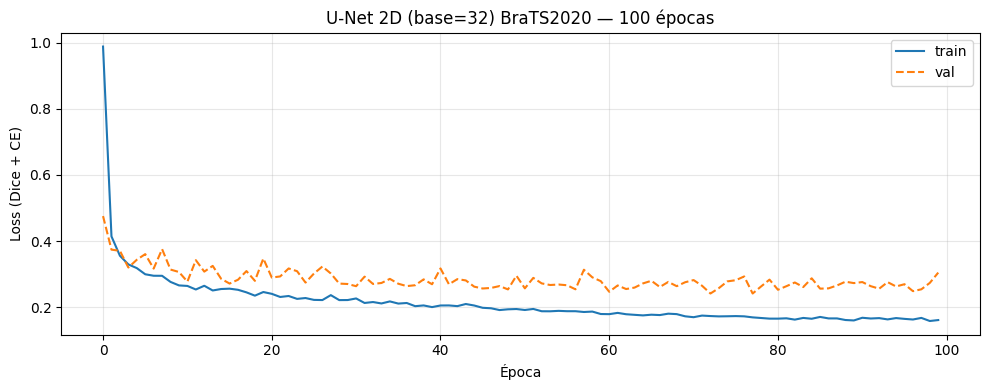

In [17]:
# Curvas de loss (treino vs validação)

hist_path = UNET2D_LOGS / "train_history.json"
if "train_history" not in vars():
    if not hist_path.exists():
        raise FileNotFoundError(
            f"Execute a célula de treino primeiro, ou verifique: {hist_path}")
    with open(hist_path) as f:
        train_history = json.load(f)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_history["train"], label="train")
ax.plot(train_history["val"],   label="val", ls="--")
ax.set_xlabel("Época")
ax.set_ylabel("Loss (Dice + CE)")
ax.set_title(f"U-Net 2D (base={UNET2D_BASE_CH}) BraTS2020 — {TRAIN_EPOCHS} épocas")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(UNET2D_LOGS / "loss_curves.png", dpi=150)
plt.show()


Paciente: BraTS20_Training_094 | split=test | z=55
Dice C1 (necrose/non-enh): 0.9134
Dice C2 (edema):           0.9096
Dice ET (enhancing):       0.9187
Dice WT:                   0.9176
Dice TC:                   0.9387



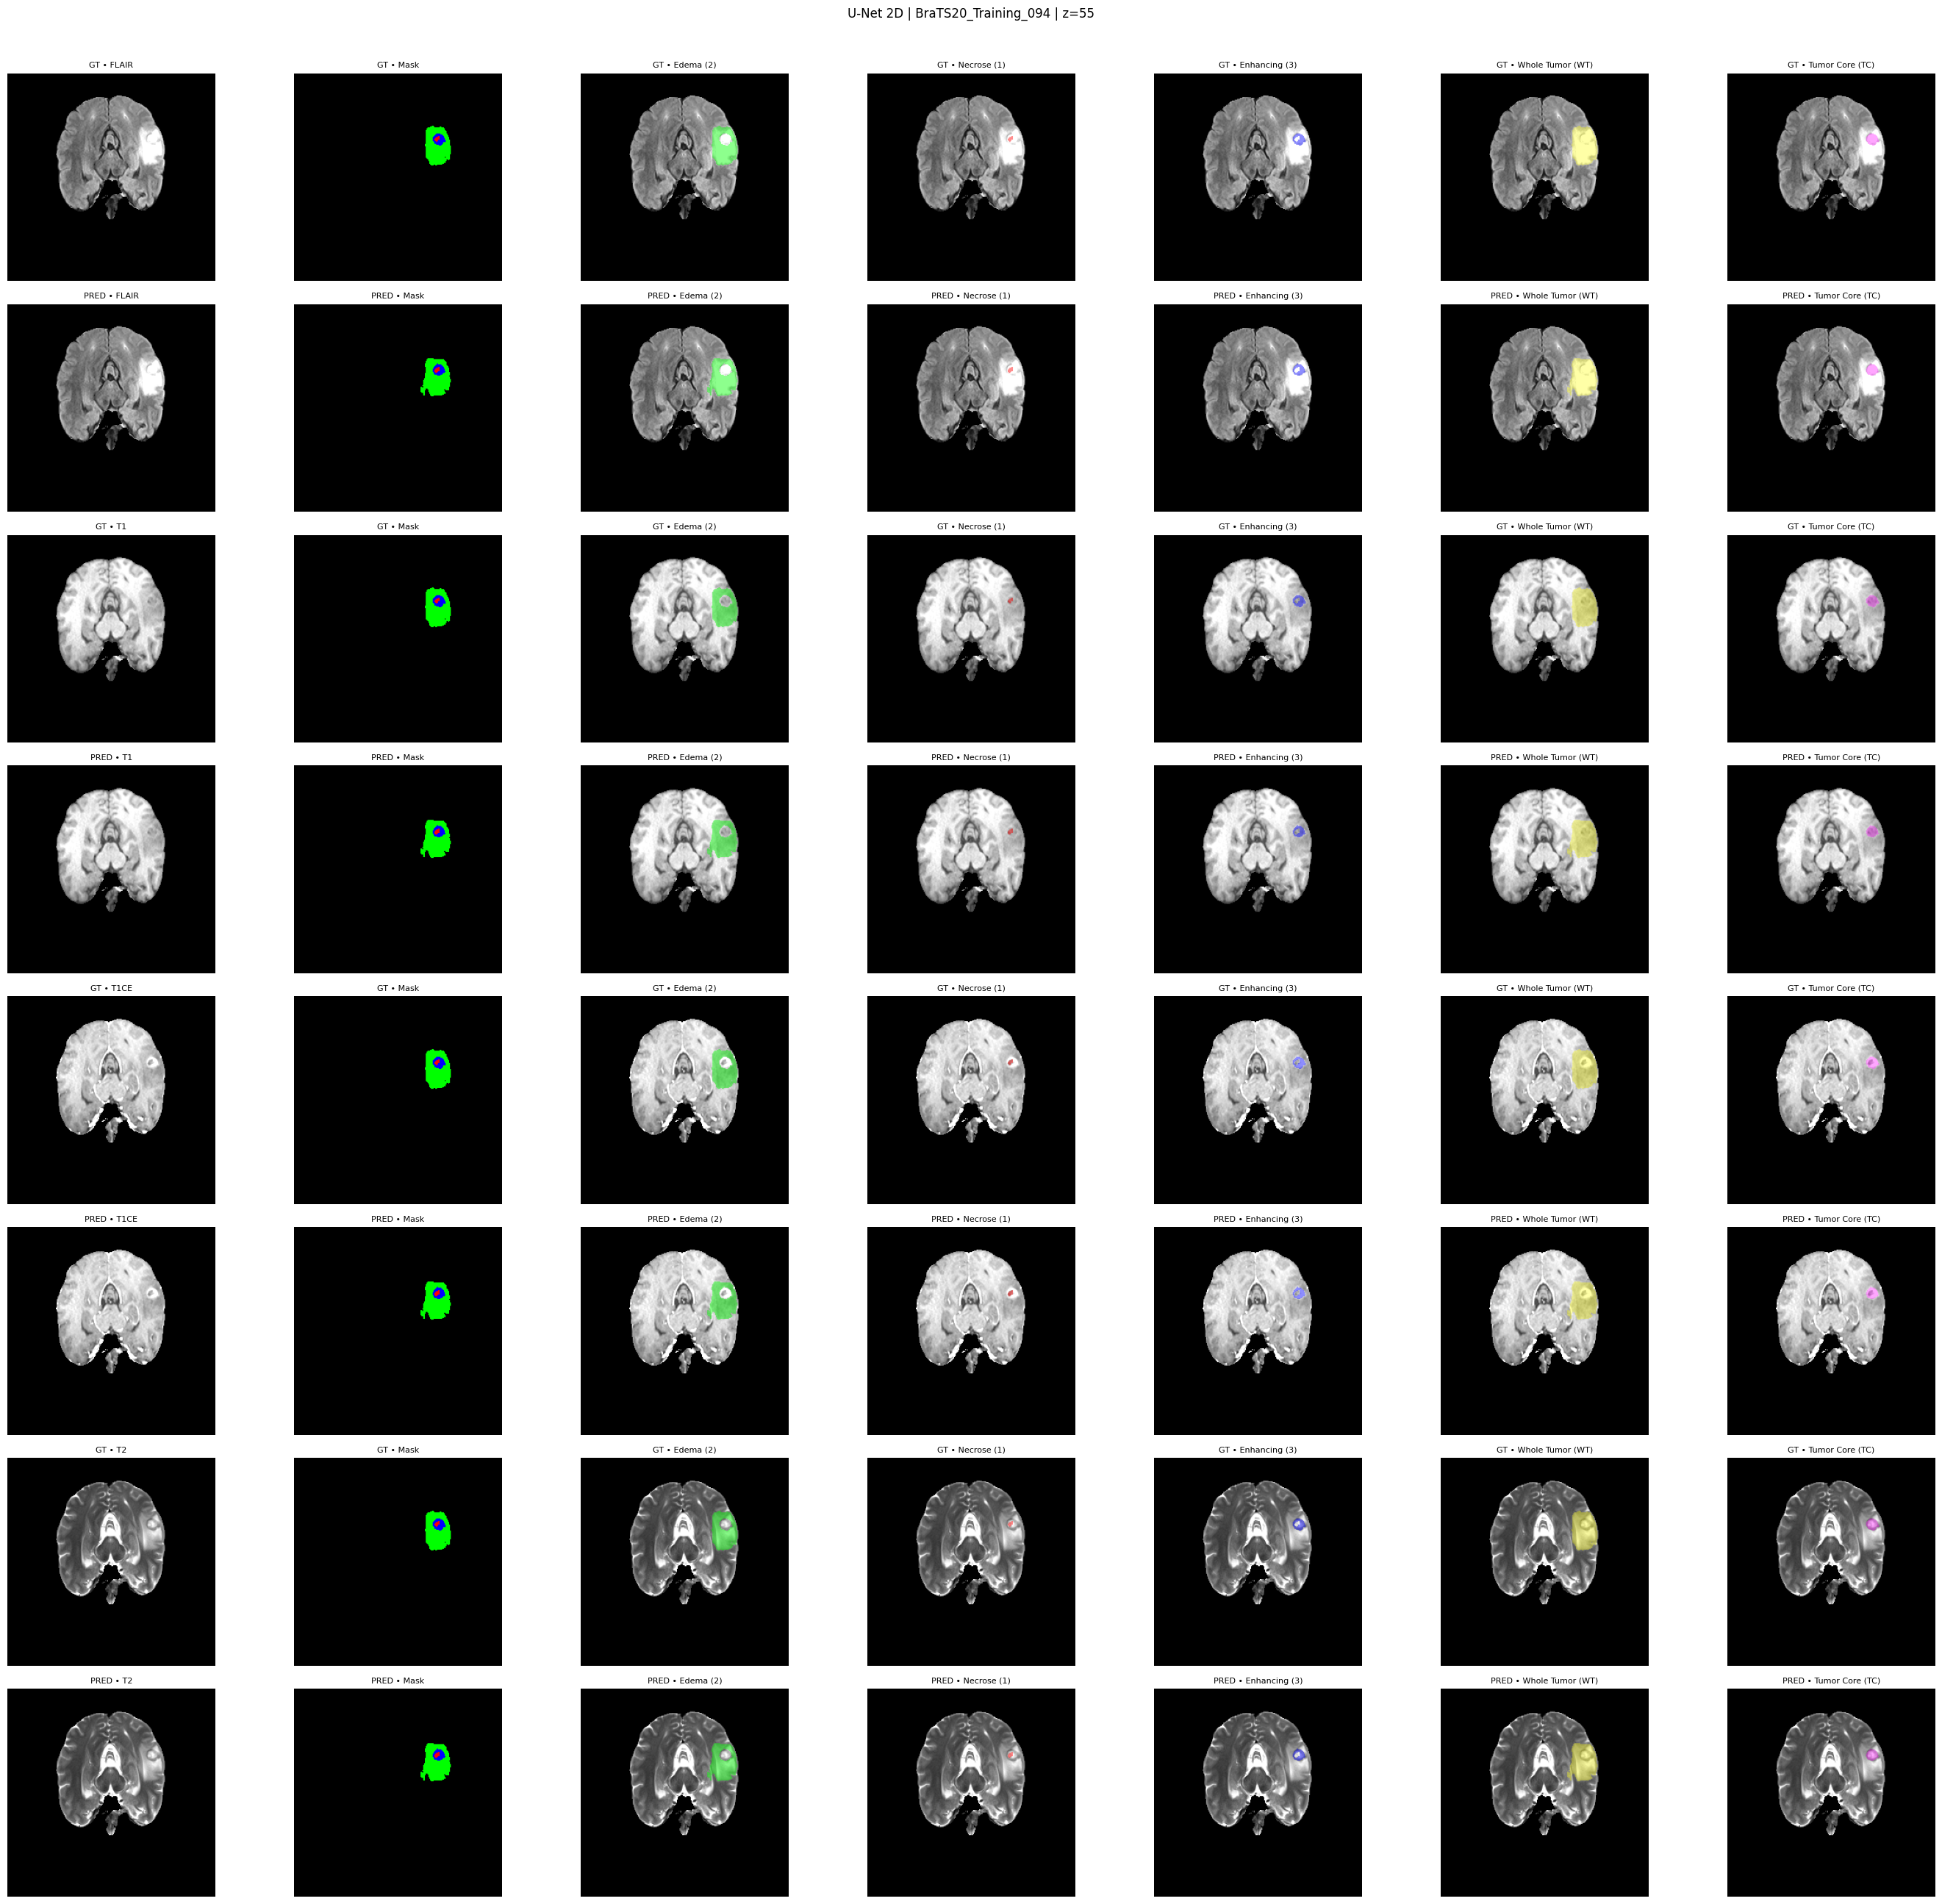

In [18]:
cmap_mask = ListedColormap([(0,0,0,1), (1,0,0,1), (0,1,0,1), (0,0,1,1)])
norm_mask = BoundaryNorm([0, 1, 2, 3, 4], cmap_mask.N)

def masks_from_seg(seg):
    nec = seg == 1; ede = seg == 2; enh = seg == 3
    wt  = (seg==1)|(seg==2)|(seg==3); tc  = (seg==1)|(seg==3)
    return nec, ede, enh, wt, tc

def overlay(ax, base2d, mask2d, color_rgb, alpha=0.45, title=""):
    ax.imshow(base2d, cmap="gray", origin="lower")
    rgba = np.zeros((*mask2d.shape, 4), dtype=np.float32)
    rgba[...,0], rgba[...,1], rgba[...,2] = color_rgb
    rgba[...,3] = mask2d.astype(np.float32) * alpha
    ax.imshow(rgba, origin="lower")
    ax.set_title(title, fontsize=8); ax.axis("off")

def plot_random_case_multimodal_gt_pred(
        ids_list, split_name="test", seed=None, z=None,
        alpha_cls=0.45, alpha_comp=0.35):
    rng = np.random.default_rng(seed)
    cid = str(rng.choice(ids_list))
    d   = case_dir(split_name, cid)

    gt = load_brats_seg(find_file(d, "seg"))
    pr = load_arr(get_pred_path(cid)).astype(np.int16)

    if z is None:
        z = pick_best_slice(gt)

    d1 = dice(gt==1, pr==1); d2 = dice(gt==2, pr==2); d3 = dice(gt==3, pr==3)
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt==1)|(gt==3)),         ((pr==1)|(pr==3)))

    print(f"\nPaciente: {cid} | split={split_name} | z={z}")
    print(f"Dice C1 (necrose/non-enh): {d1:.4f}")
    print(f"Dice C2 (edema):           {d2:.4f}")
    print(f"Dice ET (enhancing):       {d3:.4f}")
    print(f"Dice WT:                   {wt:.4f}")
    print(f"Dice TC:                   {tc:.4f}\n")

    gt2d = gt[:,:,z].T; pr2d = pr[:,:,z].T
    gt_nec,gt_ede,gt_enh,gt_wt,gt_tc = masks_from_seg(gt2d)
    pr_nec,pr_ede,pr_enh,pr_wt,pr_tc = masks_from_seg(pr2d)

    fig, axes = plt.subplots(2*len(MODS), 7, figsize=(28, 3.2*2*len(MODS)))
    fig.suptitle(f"U-Net 2D | {cid} | z={z}", y=1.01)

    for i, mod in enumerate(MODS):
        img2d = norm01(load_arr(find_file(d, mod))[:,:,z]).T
        r_gt, r_pr = 2*i, 2*i+1

        axes[r_gt,0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_gt,0].set_title(f"GT • {mod.upper()}", fontsize=8); axes[r_gt,0].axis("off")
        axes[r_gt,1].imshow(gt2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_gt,1].set_title("GT • Mask", fontsize=8); axes[r_gt,1].axis("off")
        overlay(axes[r_gt,2], img2d, gt_ede, (0,1,0), alpha_cls, "GT • Edema (2)")
        overlay(axes[r_gt,3], img2d, gt_nec, (1,0,0), alpha_cls, "GT • Necrose (1)")
        overlay(axes[r_gt,4], img2d, gt_enh, (0,0,1), alpha_cls, "GT • Enhancing (3)")
        overlay(axes[r_gt,5], img2d, gt_wt,  (1,1,0), alpha_comp,"GT • Whole Tumor (WT)")
        overlay(axes[r_gt,6], img2d, gt_tc,  (1,0,1), alpha_comp,"GT • Tumor Core (TC)")

        axes[r_pr,0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_pr,0].set_title(f"PRED • {mod.upper()}", fontsize=8); axes[r_pr,0].axis("off")
        axes[r_pr,1].imshow(pr2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_pr,1].set_title("PRED • Mask", fontsize=8); axes[r_pr,1].axis("off")
        overlay(axes[r_pr,2], img2d, pr_ede, (0,1,0), alpha_cls, "PRED • Edema (2)")
        overlay(axes[r_pr,3], img2d, pr_nec, (1,0,0), alpha_cls, "PRED • Necrose (1)")
        overlay(axes[r_pr,4], img2d, pr_enh, (0,0,1), alpha_cls, "PRED • Enhancing (3)")
        overlay(axes[r_pr,5], img2d, pr_wt,  (1,1,0), alpha_comp,"PRED • Whole Tumor (WT)")
        overlay(axes[r_pr,6], img2d, pr_tc,  (1,0,1), alpha_comp,"PRED • Tumor Core (TC)")

    plt.tight_layout(); plt.show()
    return cid, z, {"dice_c1":d1, "dice_c2":d2, "dice_ET":d3, "dice_WT":wt, "dice_TC":tc}


cid, z, dice_dict = plot_random_case_multimodal_gt_pred(test_ids, split_name="test", seed=None)

In [19]:
# [1/6] Volume tumoral por caso

vol_rows = []
for cid in tqdm(test_ids, desc="Volume tumoral GT"):
    gt_path = find_file(case_dir("test", cid), "seg")
    gt = load_brats_seg(gt_path)
    spacing = nib.load(str(gt_path)).header.get_zooms()[:3]
    voxel_mm3 = float(np.prod(spacing))

    vol_rows.append({
        "id":         cid,
        "vol_WT_mm3": int(((gt==1)|(gt==2)|(gt==3)).sum()) * voxel_mm3,
        "vol_TC_mm3": int(((gt==1)|(gt==3)).sum())         * voxel_mm3,
        "vol_ET_mm3": int((gt==3).sum())                   * voxel_mm3,
    })

df_vol = pd.DataFrame(vol_rows)

df_err = (df.merge(df_hd95, on="id")
            .merge(lw_df,   on="id")
            .merge(df_vol,  on="id"))

df_err.describe().round(3)

Volume tumoral GT: 100%|██████████| 53/53 [00:02<00:00, 19.29it/s]


,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC,lwd_WT,lwd_TC,lwd_ET,vol_WT_mm3,vol_TC_mm3,vol_ET_mm3
count,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000
mean,0.667,0.794,0.809,0.886,0.848,8.987,8.060,5.606,10.273,7.408,0.502,0.705,0.671,95115.849,38232.642,18346.698
std,0.288,0.132,0.185,0.099,0.175,15.752,9.887,15.071,18.390,15.857,0.322,0.294,0.283,57372.717,30648.866,15950.633
min,0.015,0.493,0.070,0.522,0.104,1.000,1.000,1.000,1.000,1.000,0.047,0.102,0.096,15762.000,1195.000,126.000
25%,0.553,0.694,0.751,0.863,0.832,2.828,2.236,1.000,2.236,1.414,0.238,0.464,0.406,51173.000,11695.000,4362.000
50%,0.770,0.836,0.897,0.919,0.918,5.099,4.243,1.414,3.162,2.449,0.449,0.886,0.826,80396.000,35839.000,17506.000
75%,0.893,0.897,0.911,0.945,0.952,9.055,8.062,3.000,7.348,5.831,0.917,0.948,0.908,135252.000,57282.000,29516.000
max,0.983,0.953,0.961,0.968,0.975,105.142,46.272,105.740,100.724,106.075,0.968,0.975,0.961,231951.000,153111.000,79009.000


In [20]:
# [2/6] Métricas agregadas por quartil de tamanho tumoral (quartiles do volume WT)

q25, q50, q75 = df_err["vol_WT_mm3"].quantile([0.25, 0.50, 0.75]).values

def size_bin(v):
    if v < q25: return "Q1"
    if v < q50: return "Q2"
    if v < q75: return "Q3"
    return "Q4"

df_err["size_bin"] = df_err["vol_WT_mm3"].apply(size_bin)

agg_cols = ["dice_WT", "dice_TC", "dice_ET",
            "hd95_WT", "hd95_TC", "hd95_ET",
            "lwd_WT",  "lwd_TC",  "lwd_ET"]

print(f"Limiares (vol WT em mm³): Q1 < {q25:,.0f}  |  Q2 < {q50:,.0f}  |  Q3 < {q75:,.0f}  |  Q4 ≥ {q75:,.0f}")
print(f"Contagem por quartil: {df_err['size_bin'].value_counts().to_dict()}\n")

df_err.groupby("size_bin")[agg_cols].mean().reindex(["Q1", "Q2", "Q3", "Q4"]).round(4)

Limiares (vol WT em mm³): Q1 < 51,173  |  Q2 < 80,396  |  Q3 < 135,252  |  Q4 ≥ 135,252
Contagem por quartil: {'Q4': 14, 'Q1': 13, 'Q2': 13, 'Q3': 13}



,dice_WT,dice_TC,dice_ET,hd95_WT,hd95_TC,hd95_ET,lwd_WT,lwd_TC,lwd_ET
size_bin,,,,,,,,,
Q1,0.7859,0.8179,0.8099,24.7002,14.2359,10.4624,0.3912,0.7163,0.7542
Q2,0.8930,0.8665,0.7740,8.0334,4.3508,3.0342,0.3752,0.7540,0.6370
Q3,0.9294,0.9255,0.8775,4.7167,3.9769,1.6105,0.5792,0.7773,0.7587
Q4,0.9312,0.7876,0.7765,4.1156,7.0928,7.1937,0.6514,0.5824,0.5434


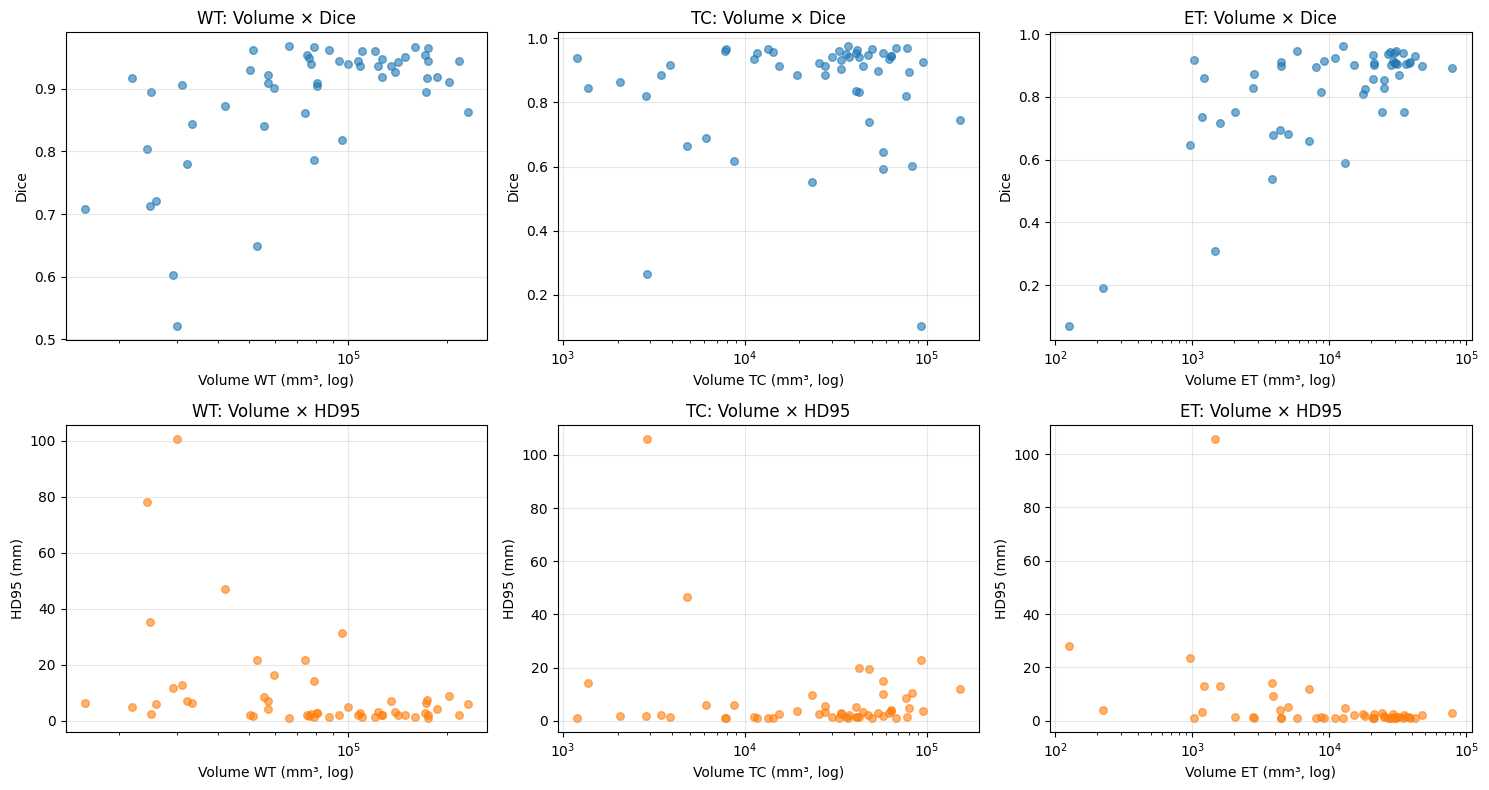

In [21]:
# [3/6] Scatter: volume tumoral × Dice e × HD95 (por região)

regions = ["WT", "TC", "ET"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for j, reg in enumerate(regions):
    vol = df_err[f"vol_{reg}_mm3"].values
    dsc = df_err[f"dice_{reg}"].values
    hsc = df_err[f"hd95_{reg}"].values

    axes[0, j].scatter(vol, dsc, alpha=0.6, s=30)
    axes[0, j].set_xscale("log")
    axes[0, j].set_xlabel(f"Volume {reg} (mm³, log)")
    axes[0, j].set_ylabel("Dice")
    axes[0, j].set_title(f"{reg}: Volume × Dice")
    axes[0, j].grid(True, alpha=0.3)

    axes[1, j].scatter(vol, hsc, alpha=0.6, s=30, color="C1")
    axes[1, j].set_xscale("log")
    axes[1, j].set_xlabel(f"Volume {reg} (mm³, log)")
    axes[1, j].set_ylabel("HD95 (mm)")
    axes[1, j].set_title(f"{reg}: Volume × HD95")
    axes[1, j].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [22]:
# [3/6] Correlação de Spearman entre volume tumoral e métricas

corr_rows = []
for reg in regions:
    v = df_err[f"vol_{reg}_mm3"].values
    d = df_err[f"dice_{reg}"].values
    h = df_err[f"hd95_{reg}"].values

    rho_d, p_d = spearmanr(v, d)
    mask = ~np.isnan(h)
    if mask.sum() > 2:
        rho_h, p_h = spearmanr(v[mask], h[mask])
    else:
        rho_h, p_h = np.nan, np.nan

    corr_rows.append({
        "regiao": reg,
        "spearman_vol×dice": round(rho_d, 3),  "p_value_dice": round(p_d, 4),
        "spearman_vol×hd95": round(rho_h, 3),  "p_value_hd95": round(p_h, 4),
    })

print("Correlação de Spearman entre volume tumoral e métricas:")
pd.DataFrame(corr_rows)

Correlação de Spearman entre volume tumoral e métricas:


,regiao,spearman_vol×dice,p_value_dice,spearman_vol×hd95,p_value_hd95
0,WT,0.510,0.0001,-0.371,0.0063
1,TC,0.052,0.7136,0.239,0.0844
2,ET,0.524,0.0001,-0.381,0.0048


In [23]:
# [4/6] Ranking dos piores casos por Dice médio (WT/TC/ET)

K_WORST = 5

df_err["dice_mean"] = df_err[["dice_WT", "dice_TC", "dice_ET"]].mean(axis=1)
df_err["hd95_mean"] = df_err[["hd95_WT", "hd95_TC", "hd95_ET"]].mean(axis=1, skipna=True)

cols_show = ["id", "dice_WT", "dice_TC", "dice_ET",
             "hd95_WT", "hd95_TC", "hd95_ET",
             "vol_WT_mm3", "vol_ET_mm3", "size_bin"]

print(f"Top {K_WORST} piores casos por Dice médio:")
worst_dice = df_err.nsmallest(K_WORST, "dice_mean")[cols_show + ["dice_mean"]].round(3)
worst_ids = worst_dice["id"].tolist()

worst_dice

Top 5 piores casos por Dice médio:


,id,dice_WT,dice_TC,dice_ET,hd95_WT,hd95_TC,hd95_ET,vol_WT_mm3,vol_ET_mm3,size_bin,dice_mean
1,BraTS20_Training_277,0.522,0.265,0.307,100.724,106.075,105.740,30073.0,1463.0,Q1,0.364
49,BraTS20_Training_291,0.944,0.592,0.070,2.236,10.100,28.007,218263.0,126.0,Q4,0.536
48,BraTS20_Training_316,0.863,0.104,0.716,5.916,22.845,13.038,231951.0,1585.0,Q4,0.561
18,BraTS20_Training_271,0.961,0.551,0.192,1.732,9.682,4.123,51173.0,224.0,Q2,0.568
17,BraTS20_Training_227,0.649,0.688,0.681,21.932,5.831,5.099,52898.0,4951.0,Q2,0.673


In [24]:
# [4/6] Ranking dos piores casos por HD95 médio

print(f"Top {K_WORST} piores casos por HD95 médio:")
df_err.nlargest(K_WORST, "hd95_mean")[cols_show + ["hd95_mean"]].round(3)

Top 5 piores casos por HD95 médio:


,id,dice_WT,dice_TC,dice_ET,hd95_WT,hd95_TC,hd95_ET,vol_WT_mm3,vol_ET_mm3,size_bin,hd95_mean
1,BraTS20_Training_277,0.522,0.265,0.307,100.724,106.075,105.740,30073.0,1463.0,Q1,104.180
3,BraTS20_Training_159,0.804,0.619,0.693,78.032,5.916,4.243,24434.0,4362.0,Q1,29.397
2,BraTS20_Training_205,0.906,0.663,0.899,12.845,46.573,1.000,31109.0,4439.0,Q1,20.139
19,BraTS20_Training_182,0.872,0.936,0.914,47.031,1.414,1.000,42233.0,9134.0,Q1,16.482
48,BraTS20_Training_316,0.863,0.104,0.716,5.916,22.845,13.038,231951.0,1585.0,Q4,13.933



Paciente: BraTS20_Training_277 | split=test | z=78
Dice C1 (necrose/non-enh): 0.0706
Dice C2 (edema):           0.5028
Dice ET (enhancing):       0.3070
Dice WT:                   0.5216
Dice TC:                   0.2645



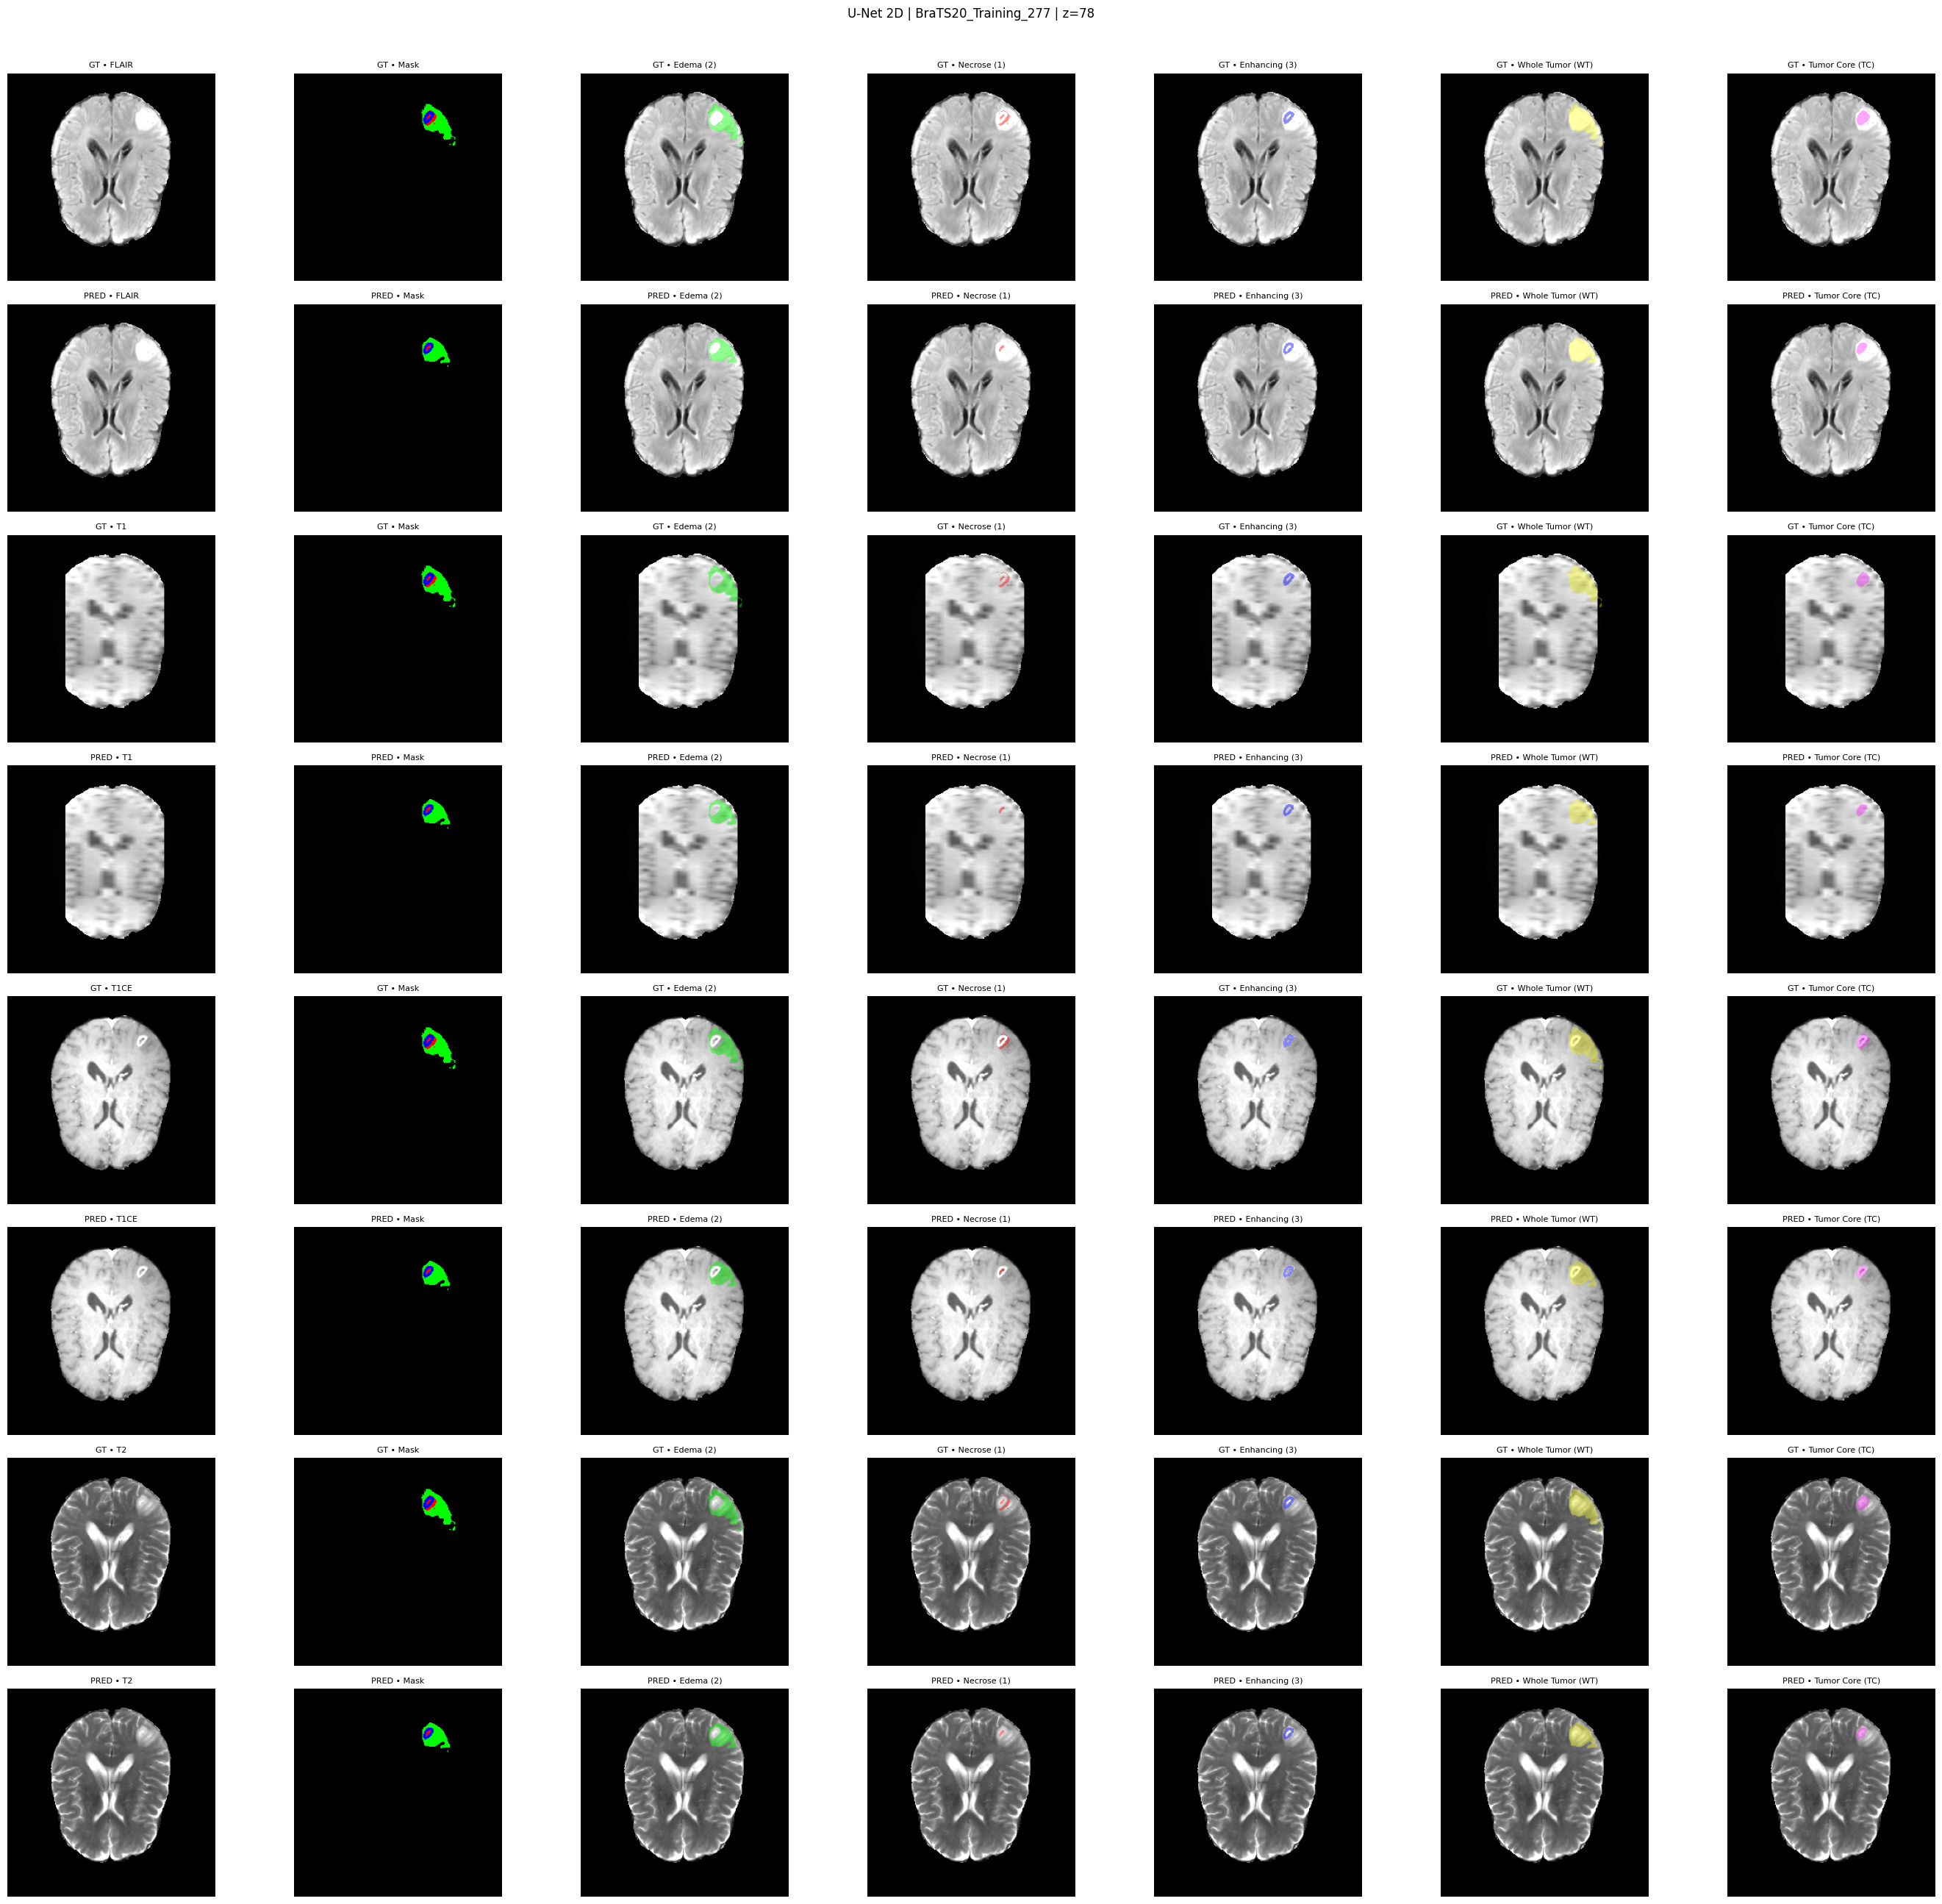

In [25]:
# [5/6] Visualização qualitativa dos piores casos

N_PLOT = min(1, len(worst_ids))

for cid in worst_ids[:N_PLOT]:
    plot_random_case_multimodal_gt_pred([cid], split_name="test", seed=0)

In [26]:
# [6/6] Análise de componentes conexos: lesões perdidas (FN) vs (FP) por caso

CC_MIN_SIZE = 50

def count_components(gt_mask, pr_mask, min_size=CC_MIN_SIZE):
    structure = np.ones((3, 3, 3), dtype=int)
    gt_lab, n_gt = cc_label(gt_mask.astype(bool), structure=structure)
    pr_lab, n_pr = cc_label(pr_mask.astype(bool), structure=structure)

    n_gt_valid = sum(1 for g in range(1, n_gt + 1) if (gt_lab == g).sum() >= min_size)
    n_pr_valid = sum(1 for p in range(1, n_pr + 1) if (pr_lab == p).sum() >= min_size)

    matched_pred, n_missed = set(), 0
    for g in range(1, n_gt + 1):
        gt_l = (gt_lab == g)
        if gt_l.sum() < min_size:
            continue
        overlap = np.unique(pr_lab[gt_l]); overlap = overlap[overlap > 0]
        if len(overlap) == 0:
            n_missed += 1
        else:
            matched_pred.update(int(p) for p in overlap)

    n_spurious = sum(1 for p in range(1, n_pr + 1)
                     if p not in matched_pred and (pr_lab == p).sum() >= min_size)
    return n_gt_valid, n_pr_valid, n_missed, n_spurious


cc_rows = []
for cid in tqdm(test_ids, desc="Componentes conexos"):
    gt = load_brats_seg(find_file(case_dir("test", cid), "seg"))
    pr = load_arr(get_pred_path(cid)).astype(np.int16)

    nw = count_components((gt==1)|(gt==2)|(gt==3), (pr==1)|(pr==2)|(pr==3))
    nt = count_components((gt==1)|(gt==3),         (pr==1)|(pr==3))
    ne = count_components((gt==3),                  (pr==3))

    cc_rows.append({"id": cid,
        "WT_n_gt": nw[0], "WT_n_pr": nw[1], "WT_missed_FN": nw[2], "WT_spurious_FP": nw[3],
        "TC_n_gt": nt[0], "TC_n_pr": nt[1], "TC_missed_FN": nt[2], "TC_spurious_FP": nt[3],
        "ET_n_gt": ne[0], "ET_n_pr": ne[1], "ET_missed_FN": ne[2], "ET_spurious_FP": ne[3],
    })

df_cc = pd.DataFrame(cc_rows)

totals = pd.DataFrame({
    "região":          ["WT", "TC", "ET"],
    "tot_lesões_GT":   [df_cc["WT_n_gt"].sum(),       df_cc["TC_n_gt"].sum(),       df_cc["ET_n_gt"].sum()],
    "tot_lesões_PR":   [df_cc["WT_n_pr"].sum(),       df_cc["TC_n_pr"].sum(),       df_cc["ET_n_pr"].sum()],
    "tot_perdidas_FN": [df_cc["WT_missed_FN"].sum(),  df_cc["TC_missed_FN"].sum(),  df_cc["ET_missed_FN"].sum()],
    "tot_espúrias_FP": [df_cc["WT_spurious_FP"].sum(),df_cc["TC_spurious_FP"].sum(),df_cc["ET_spurious_FP"].sum()],
})
totals["FN_rate_%"] = (100 * totals["tot_perdidas_FN"] / totals["tot_lesões_GT"].replace(0, np.nan)).round(2)
totals["FP_rate_%"] = (100 * totals["tot_espúrias_FP"] / totals["tot_lesões_PR"].replace(0, np.nan)).round(2)

totals

Componentes conexos: 100%|██████████| 53/53 [01:03<00:00,  1.20s/it]


,região,tot_lesões_GT,tot_lesões_PR,tot_perdidas_FN,tot_espúrias_FP,FN_rate_%,FP_rate_%
0,WT,89,177,17,93,19.10,52.54
1,TC,63,95,4,27,6.35,28.42
2,ET,78,101,6,33,7.69,32.67


In [27]:
# [6/6] Top 10 casos com mais erros de componente

print("Top 10 casos com mais erros de componente (FN+FP somados em todas as regiões):")

df_cc["err_total"] = df_cc[["WT_missed_FN","TC_missed_FN","ET_missed_FN",
                            "WT_spurious_FP","TC_spurious_FP","ET_spurious_FP"]].sum(axis=1)

df_cc.nlargest(10, "err_total")

Top 10 casos com mais erros de componente (FN+FP somados em todas as regiões):


,id,WT_n_gt,WT_n_pr,WT_missed_FN,WT_spurious_FP,TC_n_gt,TC_n_pr,TC_missed_FN,TC_spurious_FP,ET_n_gt,ET_n_pr,ET_missed_FN,ET_spurious_FP,err_total
1,BraTS20_Training_277,3,12,2,10,1,7,0,5,2,7,0,5,22
24,BraTS20_Training_064,4,17,0,13,1,1,0,0,1,1,0,0,13
25,BraTS20_Training_035,1,5,0,4,1,3,0,2,1,8,0,7,13
35,BraTS20_Training_184,2,6,1,5,2,3,1,2,2,2,1,1,11
2,BraTS20_Training_205,1,5,0,4,1,6,0,5,1,1,0,0,9
50,BraTS20_Training_175,4,4,2,1,4,1,3,0,4,1,3,0,9
8,BraTS20_Training_119,4,9,2,4,1,1,0,0,1,1,0,0,6
26,BraTS20_Training_194,1,8,0,6,1,1,0,0,1,1,0,0,6
15,BraTS20_Training_228,1,6,0,5,1,1,0,0,1,1,0,0,5
16,BraTS20_Training_084,1,5,0,3,1,2,0,1,1,2,0,1,5
